# MALCA dipper crossmatch against the 2026-07-16 literature catalog

This notebook crossmatches the current persisted MALCA Review labels for
`dat3-full-extended_2026-07-01-v4` against the spatially deduplicated
`dipper_literature_master.csv` catalog using an **8 arcsec** radius.

It is designed as an auditable snapshot rather than a transient lookup:

- the Review query and catalog paths are explicit;
- every current dipper is retained in a candidate-level audit table;
- all coordinate pairs inside the radius are retained, including future
  ambiguous matches;
- exact Gaia identifiers exposed by the literature catalog are checked
  independently;
- tables, metadata, vector PDFs, and high-resolution PNG previews are
  written to versioned output directories;
- the executed notebook embeds the current numerical results.

Coordinate proximity establishes a candidate association, not physical
confirmation. Literature evidence tiers and population flags remain
separate from the MALCA Review label.

## Configuration and reproducibility contract

The catalog is matched in full rather than prefiltered on
`recommended_crossmatch_flag`. That flag is carried into the output so
rejected or nonmember-only literature rows cannot disappear silently.
The catalog reports that coordinates were not proper-motion propagated;
the output should therefore be treated as a counterpart shortlist in
crowded or high-proper-motion fields.

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import re
import sqlite3
import sys
from datetime import datetime, timezone
from pathlib import Path

import astropy
import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord, search_around_sky
from IPython.display import Markdown, display

RUN_NAME = "dat3-full-extended_2026-07-01-v4"
CATALOG_VERSION = "2026-07-16"
MATCH_RADIUS_ARCSEC = 8.0

root_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        path
        for path in root_candidates
        if (path / "malca").is_dir()
        and (
            path
            / "output"
            / "runs"
            / RUN_NAME
            / "review"
            / "review.db"
        ).exists()
        and (
            path
            / "input"
            / f"dipper_literature_catalog_{CATALOG_VERSION}"
            / "dipper_literature_master.csv"
        ).exists()
    ),
    Path.cwd(),
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.plotting.lightcurve_publication import (
    PUBLICATION_STYLE,
    finalize_publication_figure,
)

RUN_DIR = REPO_ROOT / "output" / "runs" / RUN_NAME
DB_PATH = RUN_DIR / "review" / "review.db"
CATALOG_DIR = (
    REPO_ROOT / "input" / f"dipper_literature_catalog_{CATALOG_VERSION}"
)
CATALOG_PATH = CATALOG_DIR / "dipper_literature_master.csv"
OUTPUT_BASE = (
    RUN_DIR
    / "results"
    / f"dipper_literature_crossmatch_{CATALOG_VERSION}"
)
PDF_BASE = (
    REPO_ROOT
    / "output"
    / "pdf"
    / f"dipper_literature_crossmatch_{CATALOG_VERSION}"
)

plt.rcParams.update(
    {
        **PUBLICATION_STYLE,
        "axes.grid": False,
        "savefig.facecolor": "white",
        "savefig.transparent": False,
    }
)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

COLOR_CATALOG = "#8FB8D1"
COLOR_CANDIDATE = "#3C4043"
COLOR_MATCH = "#D55E00"
COLOR_PRIMARY = "#0072B2"
COLOR_SECONDARY = "#E69F00"
COLOR_BROAD = "#7A5195"

print(f"REPO_ROOT           = {REPO_ROOT}")
print(f"Review DB           = {DB_PATH}")
print(f"Literature catalog  = {CATALOG_PATH}")
print(f"Match radius        = {MATCH_RADIUS_ARCSEC:g} arcsec")
print(f"Python              = {platform.python_version()}")
print(f"pandas              = {pd.__version__}")
print(f"astropy             = {astropy.__version__}")
print(f"matplotlib          = {matplotlib.__version__}")

REPO_ROOT           = /Users/calder/code/malca
Review DB           = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
Literature catalog  = /Users/calder/code/malca/input/dipper_literature_catalog_2026-07-16/dipper_literature_master.csv
Match radius        = 8 arcsec
Python              = 3.10.20
pandas              = 2.2.2
astropy             = 6.1.7
matplotlib          = 3.10.9


## Load a consistent Review snapshot and the literature master

The Review cohort is defined solely by the persisted
`reviews.event_class = 'dipper'` label. Workflow/disposition fields are
retained for auditing rather than silently adding a second selection.
The SQLite read is wrapped in one transaction so the candidate rows and
snapshot timestamp are internally consistent even if Review is open.

In [2]:
DIPPER_QUERY = """
SELECT
    c.candidate_id,
    c.asas_sn_id,
    c.source_id,
    c.gaia_id,
    c.gaia_dr2_id,
    c.ra,
    c.dec,
    r.event_class,
    r.classification_confidence,
    r.status,
    r.workflow_status,
    r.disposition,
    r.morphology_primary,
    r.morphology_secondary,
    r.morphology_recurrence,
    r.physical_primary,
    r.physical_secondary,
    r.notes,
    r.updated_at
FROM reviews AS r
JOIN candidates AS c USING(candidate_id)
WHERE lower(trim(r.event_class)) = 'dipper'
ORDER BY c.candidate_id
"""

with sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True) as connection:
    connection.execute("BEGIN")
    dippers = pd.read_sql_query(DIPPER_QUERY, connection)
    latest_review_utc = connection.execute(
        """
        SELECT MAX(updated_at)
        FROM reviews
        WHERE lower(trim(event_class)) = 'dipper'
        """
    ).fetchone()[0]
    connection.rollback()

literature = pd.read_csv(CATALOG_PATH, dtype=str)
for column in ("ra_deg", "dec_deg"):
    literature[column] = pd.to_numeric(
        literature[column], errors="coerce"
    )

for column in ("ra", "dec"):
    dippers[column] = pd.to_numeric(dippers[column], errors="coerce")

if dippers.empty:
    raise RuntimeError("The Review database contains no dipper labels.")
if dippers["candidate_id"].duplicated().any():
    raise RuntimeError("Duplicate candidate IDs in the Review selection.")
if literature["master_id"].duplicated().any():
    raise RuntimeError("Duplicate master IDs in the literature catalog.")
if not np.isfinite(dippers[["ra", "dec"]].to_numpy()).all():
    raise RuntimeError("At least one Review dipper lacks finite coordinates.")
if not np.isfinite(
    literature[["ra_deg", "dec_deg"]].to_numpy()
).all():
    raise RuntimeError("At least one literature master lacks finite coordinates.")

snapshot_time = pd.Timestamp(latest_review_utc)
snapshot_stamp = snapshot_time.strftime("%Y%m%dT%H%M%SZ")
radius_slug = f"{MATCH_RADIUS_ARCSEC:g}".replace(".", "p")
SNAPSHOT_TAG = (
    f"review_{snapshot_stamp}_radius{radius_slug}arcsec"
)
OUTPUT_DIR = OUTPUT_BASE / SNAPSHOT_TAG
FIGURE_DIR = OUTPUT_DIR / "figures"
PDF_DIR = PDF_BASE / SNAPSHOT_TAG
for directory in (OUTPUT_DIR, FIGURE_DIR, PDF_DIR):
    directory.mkdir(parents=True, exist_ok=True)

review_state = (
    dippers.groupby(
        ["workflow_status", "disposition"], dropna=False
    )
    .size()
    .rename("n")
    .reset_index()
)
catalog_flag_counts = (
    literature["recommended_crossmatch_flag"]
    .fillna("missing")
    .value_counts()
    .rename_axis("recommended_crossmatch_flag")
    .rename("n")
    .reset_index()
)

print(f"Review dippers       = {len(dippers):,}")
print(f"Latest dipper update = {latest_review_utc}")
print(f"Literature masters   = {len(literature):,}")
print(f"Snapshot output      = {OUTPUT_DIR}")
print(f"Vector PDF output    = {PDF_DIR}")
display(review_state)
display(catalog_flag_counts)

Review dippers       = 182
Latest dipper update = 2026-07-29T21:28:43.942032+00:00
Literature masters   = 8,031
Snapshot output      = /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec
Vector PDF output    = /Users/calder/code/malca/output/pdf/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec


,workflow_status,disposition,n
0,reviewed,keep,182


,recommended_crossmatch_flag,n
0,yes,8024
1,no,7


## Coordinate crossmatch

The pair table below preserves **every** candidate/catalog association
within 8 arcsec. A separate one-row-per-candidate audit table stores the
nearest literature source even when it falls outside the adopted radius.
This makes near-misses, radius sensitivity, and future ambiguities
inspectable without rerunning the match.

In [3]:
candidate_coords = SkyCoord(
    ra=dippers["ra"].to_numpy(dtype=float) * u.deg,
    dec=dippers["dec"].to_numpy(dtype=float) * u.deg,
    frame="icrs",
)
literature_coords = SkyCoord(
    ra=literature["ra_deg"].to_numpy(dtype=float) * u.deg,
    dec=literature["dec_deg"].to_numpy(dtype=float) * u.deg,
    frame="icrs",
)

nearest_literature_index, nearest_separation, _ = (
    candidate_coords.match_to_catalog_sky(literature_coords)
)
candidate_index, literature_index, pair_separation, _ = (
    search_around_sky(
        candidate_coords,
        literature_coords,
        MATCH_RADIUS_ARCSEC * u.arcsec,
    )
)

db_pairs = (
    dippers.iloc[candidate_index]
    .reset_index(drop=True)
    .add_prefix("db_")
)
literature_pairs = (
    literature.iloc[literature_index]
    .reset_index(drop=True)
    .add_prefix("literature_")
)
match_pairs = pd.concat([db_pairs, literature_pairs], axis=1)
match_pairs.insert(
    len(db_pairs.columns),
    "separation_arcsec",
    pair_separation.arcsec,
)
match_pairs = match_pairs.sort_values(
    ["db_candidate_id", "separation_arcsec", "literature_master_id"]
).reset_index(drop=True)
match_pairs["match_rank_for_candidate"] = (
    match_pairs.groupby("db_candidate_id").cumcount() + 1
)

nearest_literature = literature.iloc[
    nearest_literature_index
].reset_index(drop=True)
candidate_audit = dippers.copy()
candidate_audit["nearest_separation_arcsec"] = (
    nearest_separation.arcsec
)
nearest_columns = [
    "master_id",
    "canonical_name",
    "ra_deg",
    "dec_deg",
    "recommended_crossmatch_flag",
    "core_yso_dipper_flag",
    "evidence_tier",
    "primary_or_vetted_flag",
    "population_tiers",
    "classifications",
    "candidate_qualities",
    "papers",
    "years",
    "alternate_names",
]
for column in nearest_columns:
    candidate_audit[f"nearest_literature_{column}"] = (
        nearest_literature[column].to_numpy()
    )

pair_counts = match_pairs.groupby("db_candidate_id").size()
candidate_audit["n_literature_matches_within_radius"] = (
    candidate_audit["candidate_id"]
    .map(pair_counts)
    .fillna(0)
    .astype(int)
)
candidate_audit["matched_within_radius"] = (
    candidate_audit["n_literature_matches_within_radius"] > 0
)
candidate_audit["match_radius_arcsec"] = MATCH_RADIUS_ARCSEC

primary_matches = (
    match_pairs.loc[
        match_pairs["match_rank_for_candidate"].eq(1)
    ]
    .sort_values("separation_arcsec")
    .reset_index(drop=True)
)
unmatched = candidate_audit.loc[
    ~candidate_audit["matched_within_radius"]
].sort_values("nearest_separation_arcsec")

GAIA_ID_PATTERN = re.compile(
    r"Gaia\s+DR[23]\s+([0-9]{15,20})",
    flags=re.IGNORECASE,
)


def normalized_identifier(value) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).strip()
    return text if text and text.lower() not in {"none", "nan"} else None


def catalog_gaia_identifiers(canonical_name, alternate_names) -> set[str]:
    text = " | ".join(
        str(value)
        for value in (canonical_name, alternate_names)
        if not pd.isna(value)
    )
    return set(GAIA_ID_PATTERN.findall(text))


def gaia_identifier_status(
    gaia_id,
    gaia_dr2_id,
    canonical_name,
    alternate_names,
) -> str:
    db_ids = {
        value
        for value in (
            normalized_identifier(gaia_id),
            normalized_identifier(gaia_dr2_id),
        )
        if value is not None
    }
    literature_ids = catalog_gaia_identifiers(
        canonical_name, alternate_names
    )
    if not literature_ids:
        return "not_exposed_in_literature_row"
    if db_ids & literature_ids:
        return "agrees"
    return "conflicts"


candidate_audit["nearest_gaia_identifier_status"] = (
    candidate_audit.apply(
        lambda row: gaia_identifier_status(
            row["gaia_id"],
            row["gaia_dr2_id"],
            row["nearest_literature_canonical_name"],
            row["nearest_literature_alternate_names"],
        ),
        axis=1,
    )
)
match_pairs["gaia_identifier_status"] = match_pairs.apply(
    lambda row: gaia_identifier_status(
        row["db_gaia_id"],
        row["db_gaia_dr2_id"],
        row["literature_canonical_name"],
        row["literature_alternate_names"],
    ),
    axis=1,
)
primary_matches = match_pairs.loc[
    match_pairs["match_rank_for_candidate"].eq(1)
].sort_values("separation_arcsec").reset_index(drop=True)

radius_grid = np.array(
    [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 8.0, 10.0, 30.0, 60.0]
)
radius_sensitivity = pd.DataFrame(
    {
        "radius_arcsec": radius_grid,
        "unique_candidate_matches": [
            int(np.sum(nearest_separation.arcsec <= radius))
            for radius in radius_grid
        ],
    }
)
radius_sensitivity["new_matches_since_previous_radius"] = (
    radius_sensitivity["unique_candidate_matches"]
    .diff()
    .fillna(radius_sensitivity["unique_candidate_matches"])
    .astype(int)
)

multiplicity = match_pairs.groupby("db_candidate_id").size()
n_matched = int(candidate_audit["matched_within_radius"].sum())
n_ambiguous = int((multiplicity > 1).sum())
match_fraction = n_matched / len(candidate_audit)

summary = {
    "review_dippers": int(len(candidate_audit)),
    "literature_masters": int(len(literature)),
    "match_radius_arcsec": MATCH_RADIUS_ARCSEC,
    "coordinate_pairs_within_radius": int(len(match_pairs)),
    "unique_matched_candidates": n_matched,
    "unmatched_candidates": int(len(unmatched)),
    "ambiguous_candidates": n_ambiguous,
    "match_fraction": match_fraction,
    "maximum_accepted_separation_arcsec": (
        float(primary_matches["separation_arcsec"].max())
        if len(primary_matches)
        else None
    ),
    "nearest_rejected_separation_arcsec": (
        float(unmatched["nearest_separation_arcsec"].min())
        if len(unmatched)
        else None
    ),
}

display(
    Markdown(
        f"""
        ### Current result

        - **{n_matched} of {len(candidate_audit)}** Review dippers match
          a literature master within {MATCH_RADIUS_ARCSEC:g} arcsec
          ({match_fraction:.2%}).
        - **{len(unmatched)}** candidates are unmatched.
        - **{n_ambiguous}** candidates have multiple literature masters
          inside the adopted radius.
        - The widest accepted association is
          **{summary['maximum_accepted_separation_arcsec']:.3f} arcsec**.
        - The nearest rejected source is
          **{summary['nearest_rejected_separation_arcsec']:.3f} arcsec**
          away.
        """
    )
)
display(radius_sensitivity)


        ### Current result

        - **9 of 182** Review dippers match
          a literature master within 8 arcsec
          (4.95%).
        - **173** candidates are unmatched.
        - **0** candidates have multiple literature masters
          inside the adopted radius.
        - The widest accepted association is
          **0.734 arcsec**.
        - The nearest rejected source is
          **19.378 arcsec**
          away.
        

,radius_arcsec,unique_candidate_matches,new_matches_since_previous_radius
0,0.10,4,4
1,0.25,7,3
2,0.50,8,1
3,1.00,9,1
4,2.00,9,0
5,5.00,9,0
6,8.00,9,0
7,10.00,9,0
8,30.00,10,1
9,60.00,10,0


## Matched-source table

Evidence tiers and core-YSO flags come from the literature catalog.
They describe the published source list and are not recalibrated
probabilities or independent confirmation of the MALCA label.

In [4]:
matched_display_columns = [
    "db_candidate_id",
    "db_asas_sn_id",
    "separation_arcsec",
    "literature_master_id",
    "literature_canonical_name",
    "db_classification_confidence",
    "db_morphology_secondary",
    "literature_recommended_crossmatch_flag",
    "literature_core_yso_dipper_flag",
    "literature_evidence_tier",
    "literature_papers",
    "gaia_identifier_status",
]
matched_display = primary_matches[matched_display_columns].copy()
matched_display["separation_arcsec"] = matched_display[
    "separation_arcsec"
].map(lambda value: f"{value:.3f}")
display(matched_display)

evidence_summary = (
    primary_matches["literature_evidence_tier"]
    .fillna("missing")
    .value_counts()
    .rename_axis("literature_evidence_tier")
    .rename("n_matches")
    .reset_index()
)
population_summary = (
    primary_matches["literature_core_yso_dipper_flag"]
    .fillna("missing")
    .value_counts()
    .rename_axis("core_yso_dipper_flag")
    .rename("n_matches")
    .reset_index()
)
confidence_summary = (
    primary_matches["db_classification_confidence"]
    .fillna("missing")
    .value_counts()
    .sort_index()
    .rename_axis("db_classification_confidence")
    .rename("n_matches")
    .reset_index()
)
display(evidence_summary)
display(population_summary)
display(confidence_summary)

,db_candidate_id,db_asas_sn_id,separation_arcsec,literature_master_id,literature_canonical_name,db_classification_confidence,db_morphology_secondary,literature_recommended_crossmatch_flag,literature_core_yso_dipper_flag,literature_evidence_tier,literature_papers,gaia_identifier_status
0,stv_644245387906,644245387906,0.000,DIP-05538,ASASSN-21co,1,recurrent_dips,yes,no,broad_analogue_or_inventory,fores2025 (2025),not_exposed_in_literature_row
1,stv_34360122433,34360122433,0.000,DIP-03033,ASASSN-V J060000.76-310027.83,4,single_dip,yes,no,broad_analogue_or_inventory,fores2025 (2025),not_exposed_in_literature_row
2,stv_309238625577,309238625577,0.023,DIP-01165,TIC 43488669 / Gaia DR2 3183786280737192704,4,recurrent_dips,yes,yes,author_vetted_or_explicit,tajiri2020 (2020); capistrant2022 (2022),agrees
3,stv_120259975222,120259975222,0.054,DIP-05934,TIC 312493387 / 2MASS J20140898+4029502,4,dimming_with_recovery,yes,yes,author_vetted_or_explicit,cody2025 (2025),not_exposed_in_literature_row
4,stv_206158504352,206158504352,0.104,DIP-05894,TIC 408081161 / 2MASS J19555428+1932354,4,dimming_with_recovery,yes,yes,automated_secondary_or_tentative,cody2025 (2025),not_exposed_in_literature_row
5,stv_25770235550,25770235550,0.137,DIP-07483,TIC 367286993,4,stochastic_dips,yes,yes,author_vetted_or_explicit,capistrant2022 (2022),not_exposed_in_literature_row
6,stv_111670309173,111670309173,0.204,DIP-06097,Gaia DR3 1864016601045841408,4,single_dip,yes,no,author_vetted_or_explicit,tzanidakis2025 (2025),agrees
7,stv_343598086600,343598086600,0.306,DIP-01917,NGTS 14246,1,recurrent_dips,yes,yes,author_vetted_or_explicit,moulton2023 (2023),not_exposed_in_literature_row
8,stv_369367581586,369367581586,0.734,DIP-05537,J181707-164819,4,recurrent_dips,yes,no,author_vetted_or_explicit,johantgen2025 (2025),not_exposed_in_literature_row


,literature_evidence_tier,n_matches
0,author_vetted_or_explicit,6
1,broad_analogue_or_inventory,2
2,automated_secondary_or_tentative,1


,core_yso_dipper_flag,n_matches
0,yes,5
1,no,4


,db_classification_confidence,n_matches
0,1,2
1,4,7


## Independent Gaia-identifier audit

Coordinate matching remains the primary operation. This audit searches
catalog names for explicit Gaia DR2/DR3 identifiers and compares them
with the Review candidate identifiers. It can identify an association
that should be inspected even if proper motion or a coordinate typo
moves it outside the adopted radius.

In [5]:
catalog_identifier_records = []
for row in literature.itertuples(index=False):
    identifiers = catalog_gaia_identifiers(
        row.canonical_name,
        row.alternate_names,
    )
    for identifier in sorted(identifiers):
        catalog_identifier_records.append(
            {
                "gaia_identifier": identifier,
                "literature_master_id": row.master_id,
                "literature_canonical_name": row.canonical_name,
                "literature_ra_deg": row.ra_deg,
                "literature_dec_deg": row.dec_deg,
            }
        )
catalog_identifier_index = pd.DataFrame(catalog_identifier_records)

candidate_identifier_records = []
for row in dippers.itertuples(index=False):
    for identifier_kind in ("gaia_id", "gaia_dr2_id"):
        identifier = normalized_identifier(
            getattr(row, identifier_kind)
        )
        if identifier is not None:
            candidate_identifier_records.append(
                {
                    "candidate_id": row.candidate_id,
                    "asas_sn_id": row.asas_sn_id,
                    "identifier_kind": identifier_kind,
                    "gaia_identifier": identifier,
                    "candidate_ra_deg": row.ra,
                    "candidate_dec_deg": row.dec,
                }
            )
candidate_identifier_index = pd.DataFrame(
    candidate_identifier_records
)

gaia_identifier_matches = candidate_identifier_index.merge(
    catalog_identifier_index,
    on="gaia_identifier",
    how="inner",
    validate="many_to_many",
)
if len(gaia_identifier_matches):
    identifier_candidate_coords = SkyCoord(
        gaia_identifier_matches["candidate_ra_deg"].to_numpy()
        * u.deg,
        gaia_identifier_matches["candidate_dec_deg"].to_numpy()
        * u.deg,
    )
    identifier_literature_coords = SkyCoord(
        gaia_identifier_matches["literature_ra_deg"].to_numpy()
        * u.deg,
        gaia_identifier_matches["literature_dec_deg"].to_numpy()
        * u.deg,
    )
    gaia_identifier_matches["separation_arcsec"] = (
        identifier_candidate_coords.separation(
            identifier_literature_coords
        ).arcsec
    )
    gaia_identifier_matches["within_coordinate_radius"] = (
        gaia_identifier_matches["separation_arcsec"]
        <= MATCH_RADIUS_ARCSEC
    )
    gaia_identifier_matches = gaia_identifier_matches.sort_values(
        ["candidate_id", "separation_arcsec"]
    ).reset_index(drop=True)
else:
    gaia_identifier_matches["separation_arcsec"] = pd.Series(
        dtype=float
    )
    gaia_identifier_matches["within_coordinate_radius"] = pd.Series(
        dtype=bool
    )

print(
    "Exact Gaia-identifier matches: "
    f"{gaia_identifier_matches['candidate_id'].nunique():,}"
)
print(
    "Identifier matches outside the coordinate radius: "
    f"{int((~gaia_identifier_matches['within_coordinate_radius']).sum()):,}"
)
display(gaia_identifier_matches)

Exact Gaia-identifier matches: 2
Identifier matches outside the coordinate radius: 0


,candidate_id,asas_sn_id,identifier_kind,gaia_identifier,candidate_ra_deg,candidate_dec_deg,literature_master_id,literature_canonical_name,literature_ra_deg,literature_dec_deg,separation_arcsec,within_coordinate_radius
0,stv_111670309173,111670309173,gaia_id,1864016601045841408,308.822847,33.428341,DIP-06097,Gaia DR3 1864016601045841408,308.822800,33.428300,0.203989,True
1,stv_309238625577,309238625577,gaia_id,3183786280737192704,74.999832,-8.693593,DIP-01165,TIC 43488669 / Gaia DR2 3183786280737192704,74.999837,-8.693589,0.022804,True


## Persist the auditable snapshot

The snapshot directory is keyed to the latest dipper-label timestamp.
Re-running after Review changes therefore creates a new directory instead
of overwriting the prior scientific state. Re-running against an
unchanged Review state reproduces the same snapshot name.

In [6]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


candidate_snapshot_csv = dippers.to_csv(index=False)
candidate_snapshot_hash = hashlib.sha256(
    candidate_snapshot_csv.encode("utf-8")
).hexdigest()

output_paths = {
    "candidate_input_snapshot": (
        OUTPUT_DIR / "dipper_candidates_input_snapshot.csv"
    ),
    "candidate_crossmatch_audit": (
        OUTPUT_DIR
        / f"all_candidates_nearest_literature_{radius_slug}arcsec.csv"
    ),
    "all_pairs": (
        OUTPUT_DIR
        / f"all_pairs_within_{radius_slug}arcsec.csv"
    ),
    "primary_matches": (
        OUTPUT_DIR
        / f"primary_matches_within_{radius_slug}arcsec.csv"
    ),
    "unmatched": (
        OUTPUT_DIR
        / f"unmatched_candidates_at_{radius_slug}arcsec.csv"
    ),
    "radius_sensitivity": (
        OUTPUT_DIR / "radius_sensitivity.csv"
    ),
    "gaia_identifier_matches": (
        OUTPUT_DIR / "gaia_identifier_matches.csv"
    ),
    "evidence_summary": OUTPUT_DIR / "evidence_summary.csv",
    "population_summary": OUTPUT_DIR / "population_summary.csv",
    "confidence_summary": OUTPUT_DIR / "confidence_summary.csv",
    "metadata": OUTPUT_DIR / "crossmatch_metadata.json",
    "readme": OUTPUT_DIR / "README.md",
}

dippers.to_csv(output_paths["candidate_input_snapshot"], index=False)
candidate_audit.to_csv(
    output_paths["candidate_crossmatch_audit"], index=False
)
match_pairs.to_csv(output_paths["all_pairs"], index=False)
primary_matches.to_csv(output_paths["primary_matches"], index=False)
unmatched.to_csv(output_paths["unmatched"], index=False)
radius_sensitivity.to_csv(
    output_paths["radius_sensitivity"], index=False
)
gaia_identifier_matches.to_csv(
    output_paths["gaia_identifier_matches"], index=False
)
evidence_summary.to_csv(
    output_paths["evidence_summary"], index=False
)
population_summary.to_csv(
    output_paths["population_summary"], index=False
)
confidence_summary.to_csv(
    output_paths["confidence_summary"], index=False
)

db_stat = DB_PATH.stat()
metadata = {
    **summary,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "run_name": RUN_NAME,
    "review_db": str(DB_PATH),
    "review_db_size_bytes": db_stat.st_size,
    "review_db_mtime_utc": datetime.fromtimestamp(
        db_stat.st_mtime, tz=timezone.utc
    ).isoformat(),
    "review_selection_sql": DIPPER_QUERY.strip(),
    "latest_dipper_updated_at_utc": latest_review_utc,
    "candidate_snapshot_sha256": candidate_snapshot_hash,
    "catalog_version": CATALOG_VERSION,
    "catalog_path": str(CATALOG_PATH),
    "catalog_sha256": sha256_file(CATALOG_PATH),
    "catalog_recommended_rows": int(
        literature["recommended_crossmatch_flag"].eq("yes").sum()
    ),
    "coordinate_frame": "ICRS",
    "coordinate_match_implementation": (
        "astropy.coordinates.search_around_sky"
    ),
    "proper_motion_propagated": False,
    "software": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "astropy": astropy.__version__,
        "matplotlib": matplotlib.__version__,
    },
}
output_paths["metadata"].write_text(
    json.dumps(metadata, indent=2) + "\n",
    encoding="utf-8",
)

readme = "\n".join(
    [
        "# Dipper literature crossmatch snapshot",
        "",
        f"- Run: `{RUN_NAME}`",
        f"- Review DB: `{DB_PATH}`",
        f"- Latest dipper update: `{latest_review_utc}`",
        f"- Catalog: `{CATALOG_PATH}`",
        f"- Catalog SHA-256: `{metadata['catalog_sha256']}`",
        f"- Match radius: `{MATCH_RADIUS_ARCSEC:g} arcsec`",
        f"- Review dippers: `{len(candidate_audit)}`",
        f"- Matched candidates: `{n_matched}`",
        f"- Unmatched candidates: `{len(unmatched)}`",
        f"- Ambiguous candidates: `{n_ambiguous}`",
        "",
        (
            f"`all_candidates_nearest_literature_{radius_slug}"
            "arcsec.csv` is the one-row-per-candidate audit table."
        ),
        (
            f"`all_pairs_within_{radius_slug}arcsec.csv` preserves "
            "every accepted coordinate pair."
        ),
        (
            "`crossmatch_metadata.json` records the input state, "
            "selection SQL, hashes, software versions, and summary "
            "counts."
        ),
        "",
        (
            "Coordinate proximity is a counterpart association, "
            "not physical confirmation."
        ),
        "No proper-motion propagation was applied.",
        "",
    ]
)
output_paths["readme"].write_text(readme, encoding="utf-8")

output_manifest = pd.DataFrame(
    [
        {
            "artifact": key,
            "path": str(path),
            "exists": path.exists(),
            "size_bytes": path.stat().st_size if path.exists() else 0,
        }
        for key, path in output_paths.items()
    ]
)
display(output_manifest)

,artifact,path,exists,size_bytes
0,candidate_input_snapshot,/Users/calder/code/malca/output/runs/dat3-full...,True,36383
1,candidate_crossmatch_audit,/Users/calder/code/malca/output/runs/dat3-full...,True,77157
2,all_pairs,/Users/calder/code/malca/output/runs/dat3-full...,True,7458
3,primary_matches,/Users/calder/code/malca/output/runs/dat3-full...,True,7458
4,unmatched,/Users/calder/code/malca/output/runs/dat3-full...,True,70501
5,radius_sensitivity,/Users/calder/code/malca/output/runs/dat3-full...,True,159
6,gaia_identifier_matches,/Users/calder/code/malca/output/runs/dat3-full...,True,597
7,evidence_summary,/Users/calder/code/malca/output/runs/dat3-full...,True,128
8,population_summary,/Users/calder/code/malca/output/runs/dat3-full...,True,42
9,confidence_summary,/Users/calder/code/malca/output/runs/dat3-full...,True,47


## Publication figure 1: sky distribution

The all-sky context shows the full literature master, all current Review
dippers, and the accepted 8 arcsec associations in both equatorial and
Galactic coordinates. Right ascension and Galactic longitude $l$ increase
to the left, following astronomical convention.

Saved PNG: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/figures/dipper_literature_crossmatch_sky.png
Saved PDF: /Users/calder/code/malca/output/pdf/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/dipper_literature_crossmatch_sky.pdf


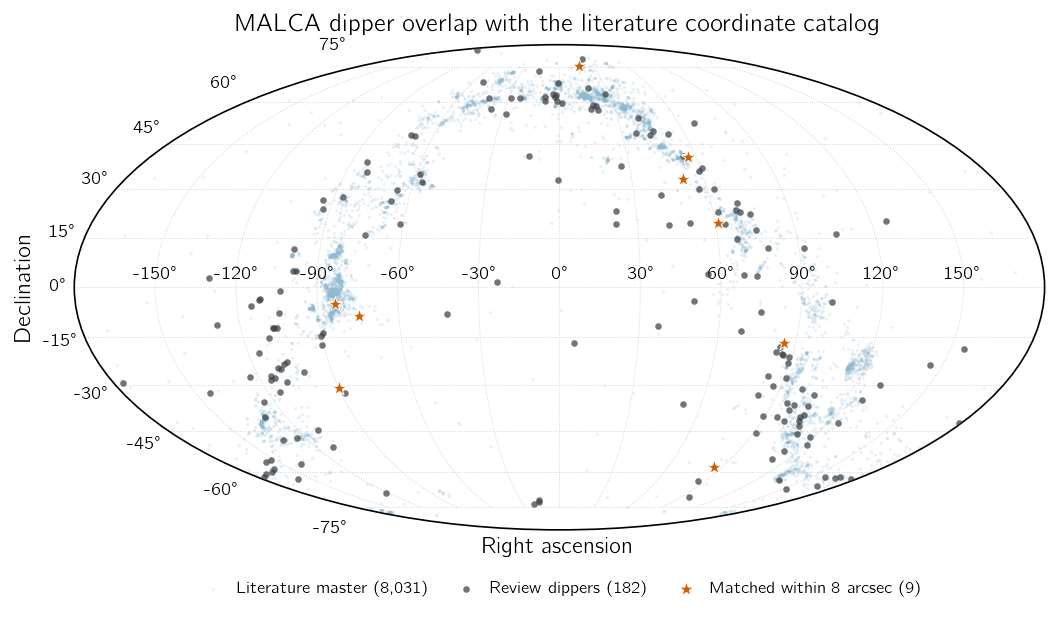

Saved PNG: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/figures/dipper_literature_crossmatch_sky_galactic.png
Saved PDF: /Users/calder/code/malca/output/pdf/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/dipper_literature_crossmatch_sky_galactic.pdf


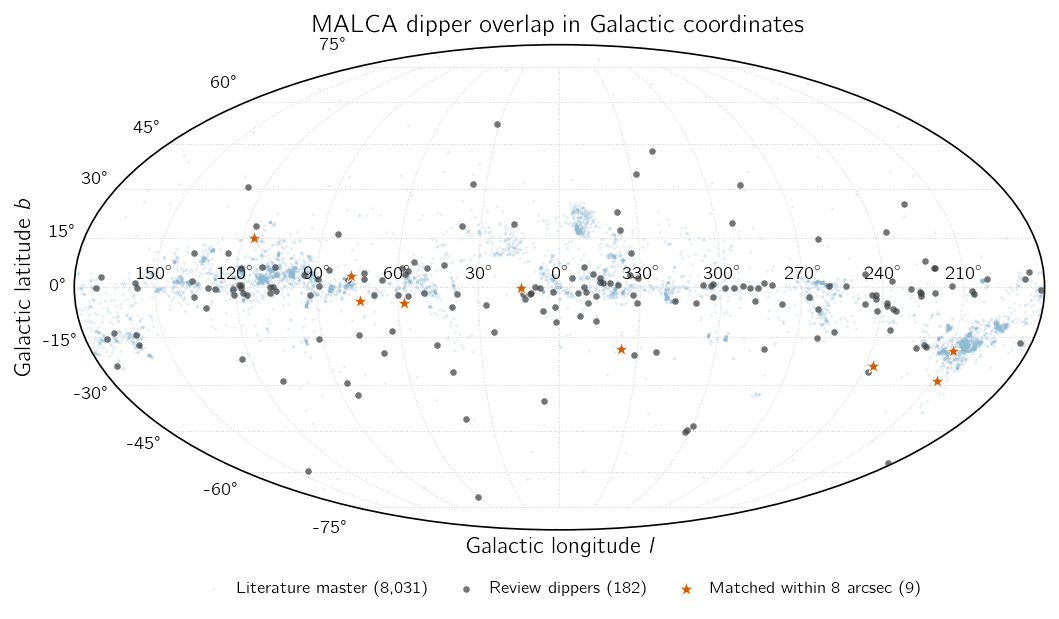

In [7]:
def mollweide_coordinates(longitude_deg, latitude_deg):
    wrapped_longitude = (
        np.asarray(longitude_deg, dtype=float) + 180.0
    ) % 360.0 - 180.0
    return (
        np.deg2rad(-wrapped_longitude),
        np.deg2rad(np.asarray(latitude_deg, dtype=float)),
    )


def export_figure_pair(fig, stem: str):
    png_path = FIGURE_DIR / f"{stem}.png"
    pdf_path = PDF_DIR / f"{stem}.pdf"
    finalize_publication_figure(fig, pad=0.45)
    fig.savefig(png_path, dpi=300, bbox_inches=None, facecolor="white")
    fig.savefig(pdf_path, bbox_inches=None, facecolor="white")
    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")
    return png_path, pdf_path


lit_lon, lit_lat = mollweide_coordinates(
    literature["ra_deg"], literature["dec_deg"]
)
dip_lon, dip_lat = mollweide_coordinates(
    dippers["ra"], dippers["dec"]
)
matched_lon, matched_lat = mollweide_coordinates(
    primary_matches["db_ra"], primary_matches["db_dec"]
)

fig = plt.figure(figsize=(7.0, 4.0))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(
    lit_lon,
    lit_lat,
    s=2.0,
    color=COLOR_CATALOG,
    alpha=0.20,
    linewidths=0,
    rasterized=True,
    label=f"Literature master ({len(literature):,})",
    zorder=1,
)
ax.scatter(
    dip_lon,
    dip_lat,
    s=10,
    color=COLOR_CANDIDATE,
    alpha=0.72,
    linewidths=0,
    label=f"Review dippers ({len(dippers):,})",
    zorder=3,
)
ax.scatter(
    matched_lon,
    matched_lat,
    s=54,
    marker="*",
    color=COLOR_MATCH,
    edgecolor="white",
    linewidth=0.45,
    label=(
        f"Matched within {MATCH_RADIUS_ARCSEC:g} arcsec "
        f"({len(primary_matches)})"
    ),
    zorder=6,
)
ax.grid(True, color="0.82", linewidth=0.45, linestyle=":")
ax.set_xlabel("Right ascension")
ax.set_ylabel("Declination")
ax.set_title(
    "MALCA dipper overlap with the literature coordinate catalog"
)
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=3,
    frameon=False,
    handletextpad=0.45,
    columnspacing=1.2,
)

sky_png, sky_pdf = export_figure_pair(
    fig, "dipper_literature_crossmatch_sky"
)
plt.show()
plt.close(fig)


literature_galactic = literature_coords.galactic
dipper_galactic = candidate_coords.galactic
matched_galactic = SkyCoord(
    ra=primary_matches["db_ra"].to_numpy(dtype=float) * u.deg,
    dec=primary_matches["db_dec"].to_numpy(dtype=float) * u.deg,
    frame="icrs",
).galactic

lit_gal_lon, lit_gal_lat = mollweide_coordinates(
    literature_galactic.l.deg,
    literature_galactic.b.deg,
)
dip_gal_lon, dip_gal_lat = mollweide_coordinates(
    dipper_galactic.l.deg,
    dipper_galactic.b.deg,
)
matched_gal_lon, matched_gal_lat = mollweide_coordinates(
    matched_galactic.l.deg,
    matched_galactic.b.deg,
)

fig = plt.figure(figsize=(7.0, 4.0))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(
    lit_gal_lon,
    lit_gal_lat,
    s=2.0,
    color=COLOR_CATALOG,
    alpha=0.20,
    linewidths=0,
    rasterized=True,
    label=f"Literature master ({len(literature):,})",
    zorder=1,
)
ax.scatter(
    dip_gal_lon,
    dip_gal_lat,
    s=10,
    color=COLOR_CANDIDATE,
    alpha=0.72,
    linewidths=0,
    label=f"Review dippers ({len(dippers):,})",
    zorder=3,
)
ax.scatter(
    matched_gal_lon,
    matched_gal_lat,
    s=54,
    marker="*",
    color=COLOR_MATCH,
    edgecolor="white",
    linewidth=0.45,
    label=(
        f"Matched within {MATCH_RADIUS_ARCSEC:g} arcsec "
        f"({len(primary_matches)})"
    ),
    zorder=6,
)
ax.grid(True, color="0.82", linewidth=0.45, linestyle=":")
galactic_tick_positions_deg = np.arange(-150, 180, 30)
galactic_tick_labels_deg = (
    -galactic_tick_positions_deg
) % 360
ax.set_xticks(np.deg2rad(galactic_tick_positions_deg))
ax.set_xticklabels(
    [rf"${value:d}^\circ$" for value in galactic_tick_labels_deg]
)
ax.set_xlabel(r"Galactic longitude $l$")
ax.set_ylabel(r"Galactic latitude $b$")
ax.set_title("MALCA dipper overlap in Galactic coordinates")
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.17),
    ncol=3,
    frameon=False,
    handletextpad=0.45,
    columnspacing=1.2,
)

galactic_sky_png, galactic_sky_pdf = export_figure_pair(
    fig, "dipper_literature_crossmatch_sky_galactic"
)
plt.show()
plt.close(fig)

## Publication figure 2: match diagnostics

The left panel gives every accepted separation. The top-right panel
shows how the result changes with radius, including the first wider
near-neighbor. The bottom-right panel preserves the literature evidence
composition of the accepted associations.

/Users/calder/code/malca/malca/plotting/lightcurve_publication.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=pad, w_pad=w_pad or pad, h_pad=h_pad or pad, rect=rect)


Saved PNG: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/figures/dipper_literature_crossmatch_diagnostics.png
Saved PDF: /Users/calder/code/malca/output/pdf/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/dipper_literature_crossmatch_diagnostics.pdf


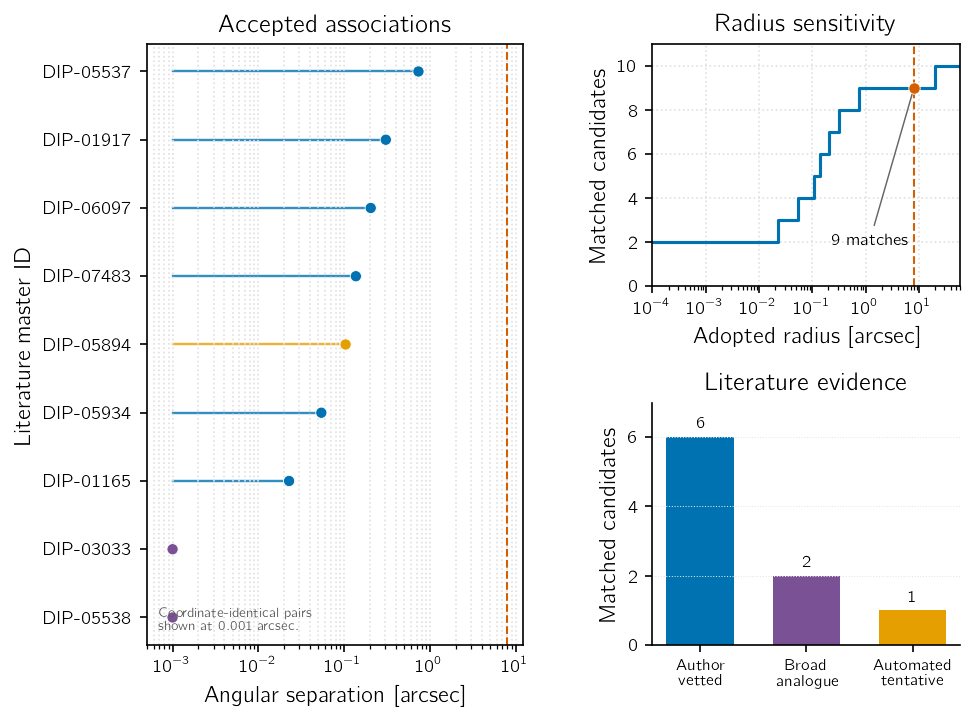

In [8]:
evidence_colors = {
    "author_vetted_or_explicit": COLOR_PRIMARY,
    "automated_secondary_or_tentative": COLOR_SECONDARY,
    "broad_analogue_or_inventory": COLOR_BROAD,
}
evidence_labels = {
    "author_vetted_or_explicit": "Author vetted",
    "automated_secondary_or_tentative": (
        "Automated tentative"
    ),
    "broad_analogue_or_inventory": "Broad analogue",
}

diagnostic_matches = primary_matches.sort_values(
    "separation_arcsec", ascending=True
).reset_index(drop=True)
plotted_separation = np.maximum(
    diagnostic_matches["separation_arcsec"].to_numpy(dtype=float),
    1.0e-3,
)
y_position = np.arange(len(diagnostic_matches))
point_colors = [
    evidence_colors.get(value, "0.45")
    for value in diagnostic_matches["literature_evidence_tier"]
]

figure = plt.figure(figsize=(7.0, 5.2))
grid = figure.add_gridspec(
    2,
    2,
    width_ratios=(1.22, 1.0),
    height_ratios=(1.0, 1.0),
    wspace=0.38,
    hspace=0.48,
)
ax_sep = figure.add_subplot(grid[:, 0])
ax_radius = figure.add_subplot(grid[0, 1])
ax_evidence = figure.add_subplot(grid[1, 1])

for y, separation, color in zip(
    y_position, plotted_separation, point_colors
):
    ax_sep.plot(
        [1.0e-3, separation],
        [y, y],
        color=color,
        linewidth=1.15,
        alpha=0.8,
        zorder=1,
    )
ax_sep.scatter(
    plotted_separation,
    y_position,
    s=29,
    c=point_colors,
    edgecolor="white",
    linewidth=0.4,
    zorder=3,
)
ax_sep.axvline(
    MATCH_RADIUS_ARCSEC,
    color=COLOR_MATCH,
    linestyle="--",
    linewidth=1.0,
    label=f"Adopted radius ({MATCH_RADIUS_ARCSEC:g} arcsec)",
)
ax_sep.set_xscale("log")
ax_sep.set_xlim(5.0e-4, 12.0)
ax_sep.set_yticks(y_position)
ax_sep.set_yticklabels(
    diagnostic_matches["literature_master_id"]
)
ax_sep.set_xlabel("Angular separation [arcsec]")
ax_sep.set_ylabel("Literature master ID")
ax_sep.set_title("Accepted associations")
ax_sep.grid(
    True, axis="x", which="both", color="0.88", linestyle=":"
)
ax_sep.text(
    0.03,
    0.02,
    "Coordinate-identical pairs\nshown at 0.001 arcsec.",
    transform=ax_sep.transAxes,
    ha="left",
    va="bottom",
    fontsize=6.5,
    color="0.35",
)

sensitivity_radius = np.geomspace(1.0e-4, 60.0, 400)
sensitivity_count = np.array(
    [
        np.sum(nearest_separation.arcsec <= radius)
        for radius in sensitivity_radius
    ]
)
ax_radius.step(
    sensitivity_radius,
    sensitivity_count,
    where="post",
    color=COLOR_PRIMARY,
    linewidth=1.5,
)
ax_radius.axvline(
    MATCH_RADIUS_ARCSEC,
    color=COLOR_MATCH,
    linestyle="--",
    linewidth=1.0,
)
ax_radius.scatter(
    [MATCH_RADIUS_ARCSEC],
    [n_matched],
    s=30,
    color=COLOR_MATCH,
    edgecolor="white",
    linewidth=0.4,
    zorder=4,
)
ax_radius.annotate(
    f"{n_matched} matches",
    xy=(MATCH_RADIUS_ARCSEC, n_matched),
    xytext=(0.58, 0.17),
    textcoords="axes fraction",
    arrowprops={
        "arrowstyle": "-",
        "color": "0.4",
        "linewidth": 0.7,
    },
    fontsize=8,
)
ax_radius.set_xscale("log")
ax_radius.set_xlim(1.0e-4, 60.0)
ax_radius.set_ylim(0, max(11, int(sensitivity_count.max()) + 1))
ax_radius.set_xlabel("Adopted radius [arcsec]")
ax_radius.set_ylabel("Matched candidates")
ax_radius.set_title("Radius sensitivity")
ax_radius.grid(
    True, axis="both", which="major", color="0.88", linestyle=":"
)

evidence_plot = evidence_summary.copy()
evidence_plot["label"] = evidence_plot[
    "literature_evidence_tier"
].map(evidence_labels).fillna(
    evidence_plot["literature_evidence_tier"]
)
evidence_plot["color"] = evidence_plot[
    "literature_evidence_tier"
].map(evidence_colors).fillna("0.45")
evidence_plot = evidence_plot.sort_values(
    "n_matches", ascending=False
).reset_index(drop=True)
evidence_plot["short_label"] = evidence_plot[
    "literature_evidence_tier"
].map(
    {
        "author_vetted_or_explicit": "Author\nvetted",
        "broad_analogue_or_inventory": "Broad\nanalogue",
        "automated_secondary_or_tentative": (
            "Automated\ntentative"
        ),
    }
).fillna(evidence_plot["label"])
evidence_x = np.arange(len(evidence_plot))
bars = ax_evidence.bar(
    evidence_x,
    evidence_plot["n_matches"],
    color=evidence_plot["color"],
    width=0.64,
)
ax_evidence.bar_label(
    bars,
    labels=[str(value) for value in evidence_plot["n_matches"]],
    padding=3,
    fontsize=8,
)
ax_evidence.set_xticks(evidence_x)
ax_evidence.set_xticklabels(
    evidence_plot["short_label"],
    fontsize=7.5,
)
ax_evidence.set_ylim(
    0, max(7, int(evidence_plot["n_matches"].max()) + 1)
)
ax_evidence.set_ylabel("Matched candidates")
ax_evidence.set_title("Literature evidence")
ax_evidence.spines["top"].set_visible(False)
ax_evidence.spines["right"].set_visible(False)
ax_evidence.grid(
    True, axis="y", color="0.90", linestyle=":", linewidth=0.5
)

diagnostic_png, diagnostic_pdf = export_figure_pair(
    figure, "dipper_literature_crossmatch_diagnostics"
)
plt.show()
plt.close(figure)

## Publication figure 3: overlap by Review morphology

This count comparison is descriptive. It does not estimate catalog
completeness because the literature master mixes surveys, evidence
tiers, and astrophysical populations.

Saved PNG: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/figures/dipper_literature_crossmatch_by_morphology.png
Saved PDF: /Users/calder/code/malca/output/pdf/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec/dipper_literature_crossmatch_by_morphology.pdf


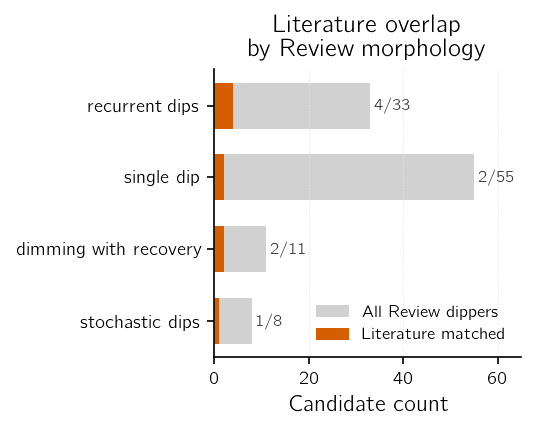

In [9]:
dippers_for_morphology = dippers.copy()
dippers_for_morphology["morphology_label"] = (
    dippers_for_morphology["morphology_secondary"]
    .fillna("")
    .str.strip()
    .replace("", "unspecified")
)
matched_candidate_ids = set(
    primary_matches["db_candidate_id"].astype(str)
)
dippers_for_morphology["literature_match"] = (
    dippers_for_morphology["candidate_id"]
    .astype(str)
    .isin(matched_candidate_ids)
)

morphology_overlap = (
    dippers_for_morphology.groupby("morphology_label")
    .agg(
        total_candidates=("candidate_id", "size"),
        matched_candidates=("literature_match", "sum"),
    )
    .reset_index()
)
morphology_overlap["match_fraction"] = (
    morphology_overlap["matched_candidates"]
    / morphology_overlap["total_candidates"]
)
matched_morphologies = morphology_overlap.loc[
    morphology_overlap["matched_candidates"] > 0
].sort_values(
    ["matched_candidates", "total_candidates"],
    ascending=[True, True],
)

figure, axis = plt.subplots(figsize=(3.5, 2.8))
y_position = np.arange(len(matched_morphologies))
axis.barh(
    y_position,
    matched_morphologies["total_candidates"],
    color="0.82",
    height=0.64,
    label="All Review dippers",
)
axis.barh(
    y_position,
    matched_morphologies["matched_candidates"],
    color=COLOR_MATCH,
    height=0.64,
    label="Literature matched",
)
axis.set_yticks(y_position)
axis.set_yticklabels(
    matched_morphologies["morphology_label"]
    .str.replace("_", " ", regex=False)
)
axis.set_xlabel("Candidate count")
axis.set_title("Literature overlap\nby Review morphology")
axis.grid(
    True, axis="x", color="0.90", linestyle=":", linewidth=0.5
)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.legend(loc="lower right", frameon=False)
for y, row in enumerate(
    matched_morphologies.itertuples(index=False)
):
    axis.text(
        row.total_candidates + 0.8,
        y,
        f"{int(row.matched_candidates)}/{int(row.total_candidates)}",
        va="center",
        ha="left",
        fontsize=8,
        color="0.25",
    )
axis.set_xlim(
    0, matched_morphologies["total_candidates"].max() * 1.18
)

morphology_png, morphology_pdf = export_figure_pair(
    figure, "dipper_literature_crossmatch_by_morphology"
)
plt.show()
plt.close(figure)

morphology_overlap.to_csv(
    OUTPUT_DIR / "morphology_overlap.csv", index=False
)

## Final integrity checks

These assertions guard the stored snapshot against accidental row loss,
radius drift, or inconsistent primary/pair tables. A later Review state
may change the counts, but the relationships must still hold.

In [10]:
assert len(candidate_audit) == len(dippers)
assert candidate_audit["candidate_id"].is_unique
assert (
    len(primary_matches)
    == candidate_audit["matched_within_radius"].sum()
)
assert (
    len(unmatched)
    + candidate_audit["matched_within_radius"].sum()
    == len(candidate_audit)
)
assert (
    primary_matches["separation_arcsec"]
    <= MATCH_RADIUS_ARCSEC
).all()
assert (
    match_pairs["separation_arcsec"] <= MATCH_RADIUS_ARCSEC
).all()
assert all(path.exists() for path in output_paths.values())
assert all(
    path.exists()
    for path in (
        sky_png,
        sky_pdf,
        galactic_sky_png,
        galactic_sky_pdf,
        diagnostic_png,
        diagnostic_pdf,
        morphology_png,
        morphology_pdf,
    )
)

final_summary = pd.DataFrame(
    [
        ("Review dippers", len(candidate_audit)),
        (
            f"Matches within {MATCH_RADIUS_ARCSEC:g} arcsec",
            len(primary_matches),
        ),
        ("Unmatched dippers", len(unmatched)),
        ("Ambiguous candidates", n_ambiguous),
        (
            "Exact Gaia-ID matches",
            gaia_identifier_matches["candidate_id"].nunique(),
        ),
    ],
    columns=["metric", "value"],
)
display(final_summary)
print("All integrity checks passed.")
print(f"Tables and metadata: {OUTPUT_DIR}")
print(f"Publication PDFs:    {PDF_DIR}")

,metric,value
0,Review dippers,182
1,Matches within 8 arcsec,9
2,Unmatched dippers,173
3,Ambiguous candidates,0
4,Exact Gaia-ID matches,2


All integrity checks passed.
Tables and metadata: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec
Publication PDFs:    /Users/calder/code/malca/output/pdf/dipper_literature_crossmatch_2026-07-16/review_20260729T212843Z_radius8arcsec
